In [ ]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import missingno as msno

In [4]:
# What are the top 10 most popular flight routes? -> route column in AirlineScrappedReview_Cleaned
# What is the distribution of bookings across flight hours? -> flight_hour in Passanger_booking_data
# By analyzing review patterns, which traveler type and class combination yields the highest and lowest ratings? -> use rating column in AirlineScrappedReview_Cleaned 

In [ ]:
df = pd.read_csv('C:/Users/user/Desktop/ACL2/data/Customer_comment.csv')

df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9424 entries, 0 to 9423
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                9424 non-null   int64 
 1   flight_number             9424 non-null   int64 
 2   origin_station_code       9424 non-null   object
 3   destination_station_code  9424 non-null   object
 4   scheduled_departure_date  9424 non-null   object
 5   arrival_delay_group       9424 non-null   object
 6   departure_delay_group     9424 non-null   object
 7   entity                    9424 non-null   object
 8   verbatim_text             9424 non-null   object
 9   seat_factor_band          9424 non-null   object
 10  ques_verbatim_text        9424 non-null   object
 11  loyalty_program_level     6920 non-null   object
 12  fleet_type_description    9424 non-null   object
 13  fleet_usage               9424 non-null   object
 14  response_group          

Unnamed: 0                     0
flight_number                  0
origin_station_code            0
destination_station_code       0
scheduled_departure_date       0
arrival_delay_group            0
departure_delay_group          0
entity                         0
verbatim_text                  0
seat_factor_band               0
ques_verbatim_text             0
loyalty_program_level       2504
fleet_type_description         0
fleet_usage                    0
response_group                 0
sentiments                     0
transformed_text            1019
dtype: int64

In [ ]:
df.head()

,Unnamed: 0,flight_number,origin_station_code,destination_station_code,scheduled_departure_date,arrival_delay_group,departure_delay_group,entity,verbatim_text,seat_factor_band,ques_verbatim_text,loyalty_program_level,fleet_type_description,fleet_usage,response_group,sentiments,transformed_text
0,0,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,There was no salad dressing. The staff informe...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B777-200,Mainline,member,Neutral,salad dress staff inform flight receiv salad d...
1,1,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,Not a choice.,0 to 70,Is there anything else you'd like to share abo...,NaN,B777-200,Mainline,non-member,Neutral,choic
2,2,1876,FLX,EWX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More variety and bigger snacks.,90+,Is there anything else you'd like to share abo...,non-elite,A320-200,Mainline,member,Neutral,varieti bigger snack
3,3,5469,SFX,SEX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,Serving pretzels and cookies in first class wa...,90+,Is there anything else you'd like to share abo...,premier gold,ERJ-175,Express,member,Neutral,serv pretzel cooki first class extrem disappoi...
4,4,281,DEX,ANX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More inflight selections to purchase for full ...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B737-MAX8,Mainline,member,Neutral,inflight select purchas full meal


In [ ]:
plt.figure(figsize=(14, 6))
msno.matrix(df)
plt.title('Missing Data Pattern - Customer Comments', fontsize=16)
plt.tight_layout()
plt.show()

missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_pct.index,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Percentage'] > 0].sort_values('Missing_Percentage', ascending=False)

print("Missing Values Summary:")
print("="*60)
print(missing_df.to_string(index=False))

In [ ]:
#filled with empty string instead of dropping
df['transformed_text'] = df['transformed_text'].fillna('')

print(f"Missing in transformed_text: {df['transformed_text'].isnull().sum()}")

In [8]:
print(df['loyalty_program_level'].value_counts())

print(f"\nNull values: {df['loyalty_program_level'].isnull().sum()}")

print(f"\nData type: {df['loyalty_program_level'].dtype}")

loyalty_program_level
non-elite           3674
premier silver       806
premier 1k           687
premier gold         564
premier platinum     428
global services      133
NBK                    1
Name: count, dtype: int64

Null values: 2112

Data type: object


In [ ]:
df['loyalty_program_level'] = df['loyalty_program_level'].fillna('None')
df.isnull().sum()

Unnamed: 0                  0
flight_number               0
origin_station_code         0
destination_station_code    0
scheduled_departure_date    0
arrival_delay_group         0
departure_delay_group       0
entity                      0
verbatim_text               0
seat_factor_band            0
ques_verbatim_text          0
loyalty_program_level       0
fleet_type_description      0
fleet_usage                 0
response_group              0
sentiments                  0
transformed_text            0
dtype: int64

In [10]:
df['departure_delay_group'] = df['departure_delay_group'].map({'Delayed': 0, 'Early & Ontime': 1})

print(df['departure_delay_group'].value_counts())

print(f"\nNull values: {df['departure_delay_group'].isnull().sum()}")

print(f"\nData type: {df['departure_delay_group'].dtype}")

departure_delay_group
1    5517
0    2888
Name: count, dtype: int64

Null values: 0

Data type: int64


In [ ]:
df3['entity'] = df3['entity'].fillna('Unknown')

print(df['entity'].value_counts())

print(f"\nNull values: {df['entity'].isnull().sum()}")

print(f"\nData type: {df['entity'].dtype}")

entity
Domestic    5808
Atlantic    1776
Latin        577
Pacific      244
Name: count, dtype: int64

Null values: 0

Data type: object


In [12]:
print(df['seat_factor_band'].value_counts())

print(f"\nNull values: {df['seat_factor_band'].isnull().sum()}")

print(f"\nData type: {df['seat_factor_band'].dtype}")

seat_factor_band
90+        5587
80+        1482
70+         700
0 to 70     636
Name: count, dtype: int64

Null values: 0

Data type: object


In [13]:
print(df['fleet_usage'].value_counts())

print(f"\nNull values: {df['fleet_usage'].isnull().sum()}")

print(f"\nData type: {df['fleet_usage'].dtype}")

fleet_usage
Mainline    7176
Express     1229
Name: count, dtype: int64

Null values: 0

Data type: object


In [14]:
df = df[df['response_group'] != 'NBK']



In [15]:
df['response_group'] = df['response_group'].map({'non-member': 0, 'member': 1})

In [16]:
print(df['response_group'].value_counts())
print(f"\nTotal rows remaining: {len(df)}")
print(df['response_group'].value_counts())

print(f"\nNull values: {df['response_group'].isnull().sum()}")

print(f"\nData type: {df['response_group'].dtype}")

response_group
1    6278
0    2126
Name: count, dtype: int64

Total rows remaining: 8404
response_group
1    6278
0    2126
Name: count, dtype: int64

Null values: 0

Data type: int64


In [17]:
df['sentiments'] = df['sentiments'].map({'Neutral': 0, 'Negative': 1})

print(df['sentiments'].value_counts())

print(f"\nNull values: {df['sentiments'].isnull().sum()}")

print(f"\nData type: {df['sentiments'].dtype}")

sentiments
0    8292
1     112
Name: count, dtype: int64

Null values: 0

Data type: int64


In [18]:
df['fleet_usage'] = df['fleet_usage'].map({'Mainline': 0, 'Express': 1})
print(df['fleet_usage'].value_counts())

print(f"\nNull values: {df['fleet_usage'].isnull().sum()}")

print(f"\nData type: {df['fleet_usage'].dtype}")

fleet_usage
0    7176
1    1228
Name: count, dtype: int64

Null values: 0

Data type: int64


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    before_dup = len(df)
    df = df.drop_duplicates()
    after_dup = len(df)
    print(f"Removed {before_dup - after_dup} duplicate rows")
else:
    print("No duplicates found!")

In [ ]:
df2 = pd.read_csv('C:/Users/user/Desktop/ACL2/data/Passanger_booking_data.csv')

df2.head()
df2.info()
df2.describe()
df2.isnull().sum()
print(f"Total missing: {df2.isnull().sum().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50002 entries, 0 to 50001
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50002 non-null  int64  
 1   sales_channel          50002 non-null  object 
 2   trip_type              50002 non-null  object 
 3   purchase_lead          50002 non-null  int64  
 4   length_of_stay         50002 non-null  int64  
 5   flight_hour            50002 non-null  int64  
 6   flight_day             50002 non-null  object 
 7   route                  50002 non-null  object 
 8   booking_origin         50002 non-null  object 
 9   wants_extra_baggage    50002 non-null  int64  
 10  wants_preferred_seat   50002 non-null  int64  
 11  wants_in_flight_meals  50002 non-null  int64  
 12  flight_duration        50002 non-null  float64
 13  booking_complete       50002 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [20]:
df2.head

<bound method NDFrame.head of        num_passengers sales_channel  trip_type  purchase_lead  length_of_stay  \
0                   1      Internet  RoundTrip             21              12   
1                   2      Internet  RoundTrip            262              19   
2                   1      Internet  RoundTrip            112              20   
3                   2      Internet  RoundTrip            243              22   
4                   1      Internet  RoundTrip             96              31   
...               ...           ...        ...            ...             ...   
49997               2      Internet  RoundTrip             27               6   
49998               1      Internet  RoundTrip            111               6   
49999               1      Internet  RoundTrip             24               6   
50000               1      Internet  RoundTrip             15               6   
50001               1      Internet  RoundTrip             19               6  

In [21]:
df2['sales_channel'] = df2['sales_channel'].map({'Internet': 0, 'Mobile': 1})

print(df2['sales_channel'].value_counts())

print(f"\nNull values: {df2['sales_channel'].isnull().sum()}")


print(f"\nData type: {df2['sales_channel'].dtype}")

sales_channel
0    44383
1     5619
Name: count, dtype: int64

Null values: 0

Data type: int64


In [22]:
print(df2['trip_type'].value_counts())

print(f"\nNull values: {df2['trip_type'].isnull().sum()}")

print(f"\nData type: {df2['trip_type'].dtype}")

trip_type
RoundTrip     49498
OneWay          387
CircleTrip      117
Name: count, dtype: int64

Null values: 0

Data type: object


In [ ]:
df2 = pd.get_dummies(df2, columns=['trip_type'], prefix='Trip', drop_first=True)

trip_cols = [col for col in df2.columns if col.startswith('Trip_')]

print(trip_cols)

In [ ]:
#one hot encoding for flight days
print("Days of the week in dataset:")

print(df2['flight_day'].value_counts())

df2 = pd.get_dummies(df2, columns=['flight_day'], prefix='Day', drop_first=True)

day_cols = [col for col in df2.columns if col.startswith('Day_')]

print(day_cols)

In [ ]:
duplicates = df2.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    before_dup = len(df2)
    df2 = df2.drop_duplicates()
    after_dup = len(df2)
    print(f"Removed {before_dup - after_dup} duplicate rows")
else:
    print("No duplicates found!")

In [ ]:
numerical_cols = ['purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df2[col].dropna(), vert=True)
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Booking Data showing outliers ', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [23]:
df3 = pd.read_csv('C:/Users/user/Desktop/ACL2/data/Survey data_Inflight Satisfaction Score.csv')

df3.head()
df3.info()
df3.describe()
df3.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47074 entries, 0 to 47073
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   flight_number                     47074 non-null  int64 
 1   origin_station_code               47074 non-null  object
 2   destination_station_code          47074 non-null  object
 3   record_locator                    47074 non-null  object
 4   scheduled_departure_date          47074 non-null  object
 5   question_text                     47074 non-null  object
 6   score                             47074 non-null  object
 7   satisfaction_type                 34963 non-null  object
 8   driver_sub_group1                 47074 non-null  object
 9   driver_sub_group2                 47074 non-null  object
 10  arrival_delay_minutes             47074 non-null  int64 
 11  arrival_delay_group               47074 non-null  object
 12  cabin_code_desc   

flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                   12111
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
cabin_name                          19980
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level               11616
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                

In [24]:
df3.head

<bound method NDFrame.head of        flight_number origin_station_code destination_station_code  \
0               3802                 MKX                      ORX   
1               4645                 COX                      DEX   
2               5236                 COX                      DEX   
3               4686                 DEX                      COX   
4                671                 DEX                      COX   
...              ...                 ...                      ...   
47069              2                 SFX                      SIX   
47070              2                 SFX                      SIX   
47071              3                 SIX                      SFX   
47072              3                 SIX                      SFX   
47073              2                 SFX                      SIX   

      record_locator scheduled_departure_date  \
0             CYXXJJ                 9/1/2022   
1             DRXXMH                 9/1/20

In [ ]:
missing_pct = (df3.isnull().sum() / len(df3)) * 100
missing_df = pd.DataFrame({
    'Column': missing_pct.index,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Percentage'] > 0].sort_values('Missing_Percentage', ascending=False)

print("\nMissing Values Summary:")
print("="*60)
print(missing_df.to_string(index=False))

In [ ]:
df3['entity'] = df3['entity'].dropna('Unknown')

In [ ]:
df3['satisfaction_type'] = df3['satisfaction_type'].fillna('Neutral')

print(df3['satisfaction_type'].value_counts())

satisfaction_type
0.0    22353
1.0    12610
Name: count, dtype: int64

Null values: 12111

Data type: float64


In [ ]:
satisfaction_mapping = {'Dissatisfied': 0, 'Neutral': 1, 'Satisfied': 2}

df3['satisfaction_type'] = df3['satisfaction_type'].map(satisfaction_mapping)

print(df3['satisfaction_type'].value_counts())

print(f"\nNull values: {df3['satisfaction_type'].isnull().sum()}")

print(f"\nData type: {df3['satisfaction_type'].dtype}")


In [26]:
df3['international_domestic_indicator'] = df3['international_domestic_indicator'].map({'Domestic': 0, 'International': 1})

print(df3['international_domestic_indicator'].value_counts())

print(f"\nNull values: {df3['international_domestic_indicator'].isnull().sum()}")

print(f"\nData type: {df3['international_domestic_indicator'].dtype}")

international_domestic_indicator
0    29242
1    17832
Name: count, dtype: int64

Null values: 0

Data type: int64


In [27]:
print(df3['response_group'].value_counts())

print(f"\nNull values: {df3['response_group'].isnull().sum()}")

print(f"\nData type: {df3['response_group'].dtype}")

response_group
member        35382
non-member    11689
NBK               3
Name: count, dtype: int64

Null values: 0

Data type: object


In [28]:
most_common = df3['media_provider'].mode()[0]

print(f"Most common category: {most_common}\n")

df3['media_provider'].fillna(most_common, inplace=True)

Most common category: PANASONIC



C:\Users\user\AppData\Local\Temp\ipykernel_14592\1811113991.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df3['media_provider'].fillna(most_common, inplace=True)


In [29]:
print(df3['media_provider'].value_counts())

print(f"\nNull values: {df3['media_provider'].isnull().sum()}")

print(f"\nData type: {df3['media_provider'].dtype}")

media_provider
PANASONIC    26518
THALES       12765
GOGO          3907
VIASAT        3884
Name: count, dtype: int64

Null values: 0

Data type: object


In [30]:
print(df3['hub_spoke'].value_counts())

print(f"\nNull values: {df3['hub_spoke'].isnull().sum()}")

print(f"\nData type: {df3['hub_spoke'].dtype}")

hub_spoke
hub departure      24343
spoke departure    22731
Name: count, dtype: int64

Null values: 0

Data type: object


In [ ]:
print(df3['cabin_name'].value_counts())
print(f"\nMissing: {df3['cabin_name'].isnull().sum()} ({(df3['cabin_name'].isnull().sum() / len(df3) * 100):.1f}%)")

df3['cabin_name'] = df3['cabin_name'].fillna('Unknown')

print("\n Filled cabin_name with 'Unknown' instead of dropping the column")
print("\nNew distribution:")
print(df3['cabin_name'].value_counts())

In [32]:
null_loyalty = df3[df3['loyalty_program_level'].isna()]

print(null_loyalty.shape[0])

print(null_loyalty['response_group'].value_counts())

all_non_member = null_loyalty['response_group'].eq('non-member').all()

print(all_non_member)

11616
response_group
non-member    11616
Name: count, dtype: int64
True


In [33]:
df3['loyalty_program_level'] = df3['loyalty_program_level'].fillna('None')
df3.isnull().sum()

flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                   12111
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level                   0
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                      0
haul_type                         

In [34]:
print(df3['loyalty_program_level'].value_counts())

print(f"\nNull values: {df3['loyalty_program_level'].isnull().sum()}")

print(f"\nData type: {df3['loyalty_program_level'].dtype}")

loyalty_program_level
non-elite           19331
None                11616
premier silver       4857
premier 1k           4334
premier gold         3362
premier platinum     2637
global services       934
NBK                     3
Name: count, dtype: int64

Null values: 0

Data type: object


In [35]:
df3.drop(columns=['departure_gate'], inplace=True)

In [36]:
df3.drop(columns=['arrival_gate'], inplace=True)

In [37]:
print(df3['score'].value_counts())

print(f"\nNull values: {df3['score'].isnull().sum()}")

print(f"\nData type: {df3['score'].dtype}")

score
2                         8250
1                         7713
5                         6733
3                         6390
4                         5877
chicken entrée            4936
other (specify)           2982
vegetarian entrée         2010
beef entrée                896
sandwich/burger/wrap       666
seafood entrée             403
snack basket selection     218
Name: count, dtype: int64

Null values: 0

Data type: object


In [ ]:
duplicates = df3.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    before_dup = len(df3)
    df3 = df3.drop_duplicates()
    after_dup = len(df3)
    print(f"Removed {before_dup - after_dup} duplicate rows")
else:
    print("No duplicates found!")

In [38]:
analyzer = SentimentIntensityAnalyzer()

df4 = pd.read_csv('C:/Users/user/Desktop/ACL2/data/AirlineScrappedReview_Cleaned.csv')


In [ ]:
df4.head()
df4.info()
df4.describe()

NameError: name 'df4' is not defined

In [ ]:
print(df4['Verified'].value_counts())

df4['Verified'] = df4['Verified'].map({'TRUE': 1, 'FALSE': 0})

print("\n✓ Encoded Verified: TRUE=1, FALSE=0")
print("\nDistribution:")
print(df4['Verified'].value_counts())

In [ ]:
print(df4['Class'].value_counts())

class_mapping = {
    'Economy Class': 0,
    'Premium Economy': 1,
    'Business Class': 2,
    'First Class': 3
}

df4['Class_Encoded'] = df4['Class'].map(class_mapping)

print("\n✓ Encoded Class with natural order:")
for cls, code in class_mapping.items():
    print(f"  {cls} → {code}")

In [ ]:
print("Current Traveller_Type values:")
print(df4['Traveller_Type'].value_counts())

df4 = pd.get_dummies(df4, columns=['Traveller_Type'], prefix='Traveller', drop_first=True)

print("\n✓ One-Hot Encoded Traveller_Type")
print("New columns created:")
traveller_cols = [col for col in df4.columns if col.startswith('Traveller_')]
print(traveller_cols)

In [39]:
def get_sentiment_scores(text):
    if pd.isna(text):
        return None
    scores = analyzer.polarity_scores(str(text))
    return scores['compound']  

df4['sentiment_score'] = df4['Review_content'].apply(get_sentiment_scores)

print(df4[['Review_content' , 'sentiment_score']].head())

                                      Review_content  sentiment_score
0  The airline lost my luggage and was absolutely...          -0.7990
1  We booked on the BA website, round trip flight...           0.0219
2  First time flying with BA business class, neve...          -0.7096
3  You can buy sandwiches and crisps but don't ex...          -0.5849
4  This is a two-for-one review covering economy ...           0.9789


In [40]:
def categorize_sentiment(score):
    if pd.isna(score):
        return 'Unknown'
    elif score >= 0.01:
        return 'Positive'
    elif score <= -0.01:
        return 'Negative'
    else:
        return 'Neutral'

df4['sentiment_category'] = df4['sentiment_score'].apply(categorize_sentiment)

print(df4['sentiment_category'].value_counts())

sentiment_category
Positive    2097
Negative    1464
Neutral       14
Name: count, dtype: int64


In [41]:
df4.to_csv('AirlineScrappedReview_with_sentiment.csv', index=False)

In [42]:
print(df4[['Review_content', 'sentiment_score', 'sentiment_category']].head(10))

                                      Review_content  sentiment_score  \
0  The airline lost my luggage and was absolutely...          -0.7990   
1  We booked on the BA website, round trip flight...           0.0219   
2  First time flying with BA business class, neve...          -0.7096   
3  You can buy sandwiches and crisps but don't ex...          -0.5849   
4  This is a two-for-one review covering economy ...           0.9789   
5  Absolutely horrible airline. Communication is ...          -0.8932   
6  Having experienced delays and cancellations de...           0.0516   
7  Travelled to Heathrow to Kalamata and return j...           0.7900   
8  This flight failed at every level. We were del...           0.8693   
9  Beware of British Airways and their marketing ...          -0.5519   

  sentiment_category  
0           Negative  
1           Positive  
2           Negative  
3           Negative  
4           Positive  
5           Negative  
6           Positive  
7           

In [43]:
print(df4['Route'].value_counts())

print(f"\nNull values: {df4['Route'].isnull().sum()}")

print(f"\nData type: {df4['Route'].dtype}")

Route
London to Johannesburg        16
London to Cape Town           15
LHR to MIA                    13
Vancouver to London           13
Johannesburg to London        13
                              ..
London to Funchal              1
Gatwick to Antalya             1
London Heathrow to Funchal     1
Heathrow to Bodrum             1
CPT to GVA via LHR             1
Name: count, Length: 1541, dtype: int64

Null values: 766

Data type: object


In [44]:
top_10_routes = df4['Route'].value_counts().head(10)

print("\nTop 10 Most Popular Flight Routes:")
print(top_10_routes)


Top 10 Most Popular Flight Routes:
Route
London to Johannesburg    16
London to Cape Town       15
LHR to MIA                13
Vancouver to London       13
Johannesburg to London    13
Cape Town to London       13
BKK to LHR                13
Hong Kong to London       11
London to Athens          11
London to Hong Kong       11
Name: count, dtype: int64


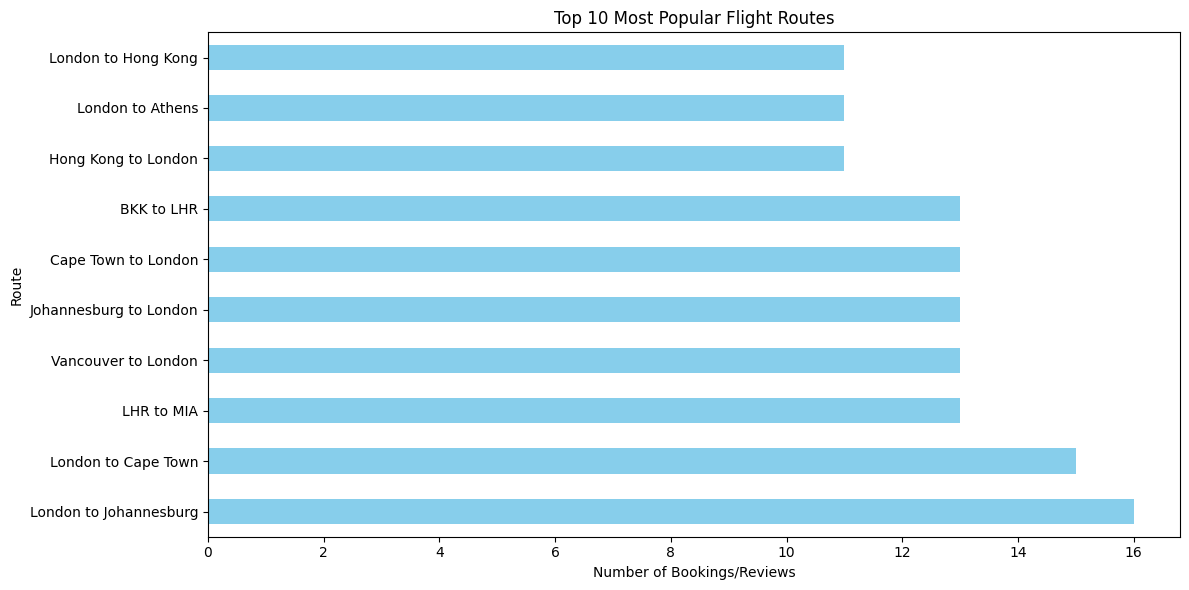

In [45]:
plt.figure(figsize=(12, 6))
top_10_routes.plot(kind='barh', color='skyblue')
plt.xlabel('Number of Bookings/Reviews')
plt.ylabel('Route')
plt.title('Top 10 Most Popular Flight Routes')
plt.tight_layout()
plt.show()